# train - test data generation for gLVs with random, sparse interaction networks.

> ### Reproducibility &amp; data
>
> This notebook reproduces **data-preprocessing**: builds the deterministic 80/20 split (`random_state=42`) for the network `saved_sims/`. Heavy arrays are archived on Zenodo.
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

### generate target datasets (n_target = 2 - 10) for bounded gLV with random interaction network (different sparsity) and randomized background

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

## split the simulated time series

we retrieve the 10-target datasets for each model, reorganize and train-test split the 10-target datasets
- model 2: p = 0;
- model 3: p = 0.01;
- model 4: p = 0.02;
- model 5: p = 0.05;
- model 6: p = 0.1;
- model 7: p = 0.2;
- model 8: p = 0.5;

In [2]:
for model_index in range(2,9):
    original_data=np.loadtxt(
        f"./saved_sims/I{model_index}/bgLV_T10_random.txt")
    N_Sample = int(original_data.shape[0]/10)
    X=[]
    for i in range(N_Sample):
        data=original_data[i*10:(i+1)*10,:]
        X.append(data)
    X=np.array(X)
    xmax = np.max(X)
    X = X/xmax
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    np.save(f"./saved_sims/I{model_index}/bgLV_T10_random_train.npy",X_train)
    np.save(f"./saved_sims/I{model_index}/bgLV_T10_random_test.npy",X_test)

In [3]:
for model_index in range(2,9):
    X_10_train = np.load(f"./saved_sims/I{model_index}/bgLV_T10_random_train.npy")
    X_10_test = np.load(f"./saved_sims/I{model_index}/bgLV_T10_random_test.npy")
    for n_target in range(2,10,1):
        X_train = X_10_train[:,:n_target,:]
        X_test = X_10_test[:,:n_target,:]
        np.save(f"./saved_sims/I{model_index}/bgLV_T{n_target}_random_train.npy",X_train)
        np.save(f"./saved_sims/I{model_index}/bgLV_T{n_target}_random_test.npy",X_test)

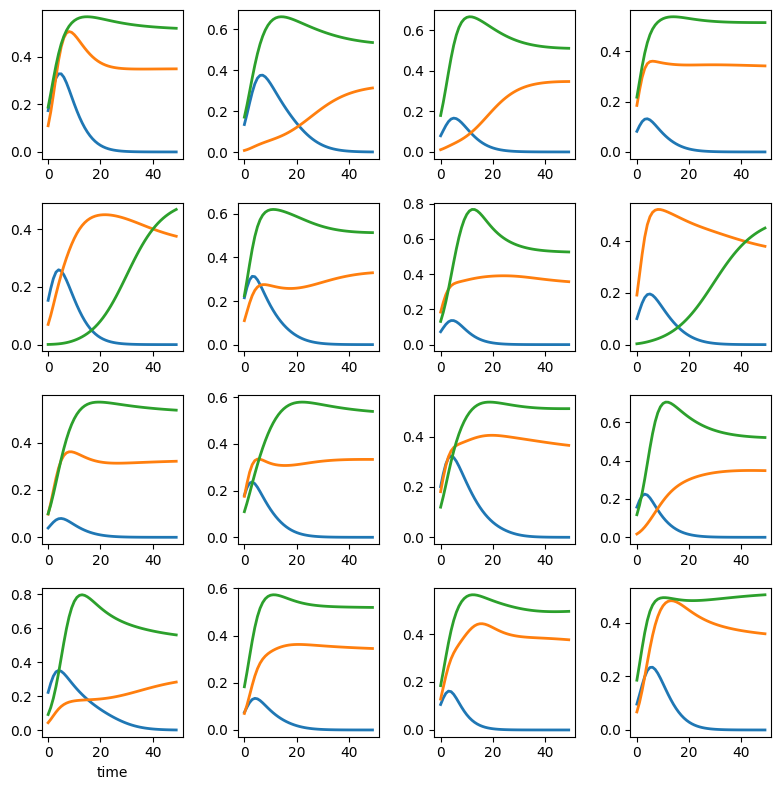

In [4]:
import matplotlib.pyplot as plt
n_target = 3
model_index = 6
X_test = np.load(f"./saved_sims/I{model_index}/bgLV_T{n_target}_random_test.npy")
fig,axes=plt.subplots(4,4,figsize=(8,8))
axes=axes.flat
for i,ax in enumerate(axes):
    y_target = X_test[i]
    for j in range(n_target):
        ax.plot(y_target[j,:],lw=2)
ax=axes[12]
ax.set_xlabel("time")
fig.tight_layout()
        

## split all member dataset

for model 4 (p = 0.02) and 5 (p=0.05), we also generated a dataset recording the time-series of every individual member. We also split them into train and test datasets, so we can deduce the critical dimension of each member, and how they are correlated with their network features (degree and centrality).

In [2]:
for model_index in range(4,6):
    original_data=np.loadtxt(
        f"./saved_sims/I{model_index}/bgLV_random_all.txt")
    N_Sample = int(original_data.shape[0]/100)
    X=[]
    for i in range(N_Sample):
        data=original_data[i*100:(i+1)*100,:]
        X.append(data)
    X=np.array(X)
    xmax = np.max(X)
    X = X/xmax
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    np.save(f"./saved_sims/I{model_index}/bgLV_all_train.npy",X_train)
    np.save(f"./saved_sims/I{model_index}/bgLV_all_test.npy",X_test)